In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
SEQUENCE_LENGTH = 63
BATCH_SIZE = 256

TEST_START = pd.Timestamp("2020-01-01")

TARGET_VOLATILITY = 0.15

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [3]:
def find_project_root(
    marker: str = "pyproject.toml",
) -> Path:

    start = Path.cwd().resolve()

    for candidate in (start, *start.parents):
        if (candidate / marker).exists():
            return candidate

    raise FileNotFoundError(
        f"Project root not found: {marker}"
    )


PROJECT_ROOT = find_project_root()

PROCESSED_DIR = (
    PROJECT_ROOT / "data" / "processed"
)

MODEL_DIR = (
    PROJECT_ROOT / "models"
)

RESULTS_DIR = (
    PROJECT_ROOT / "results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


DATA_FILE = (
    PROCESSED_DIR / "lstm_mse_features.csv"
)

PRICE_FILE = (
    PROCESSED_DIR / "adjusted_close_prices.csv"
)

SCALER_FILE = (
    MODEL_DIR / "lstm_mse_standard_scaler.joblib"
)

MODEL_FILE = (
    MODEL_DIR / "lstm_mse_best_model.pt"
)

In [4]:
for required_file in [
    DATA_FILE,
    PRICE_FILE,
    SCALER_FILE,
    MODEL_FILE,
]:
    assert required_file.exists(), (
        f"Missing file: {required_file}"
    )

print("All required files are available.")

All required files are available.


In [5]:
data = pd.read_csv(
    DATA_FILE,
    parse_dates=["date"],
)

data = (
    data
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
)

prices = pd.read_csv(
    PRICE_FILE,
    index_col=0,
    parse_dates=True,
)

scaler = joblib.load(
    SCALER_FILE
)

In [6]:
FEATURE_COLUMNS = [
    "momentum_1d",
    "momentum_21d",
    "momentum_63d",
    "momentum_126d",
    "momentum_252d",
    "macd_8_24",
    "macd_16_48",
    "macd_32_96",
    "annualized_volatility",
]

TARGET_COLUMN = "target_next_return"

In [7]:
raw_data=data.copy()

In [8]:
from torch.compiler import F


scaled_data=data.copy()
scaled_data[FEATURE_COLUMNS]=(
    scaler.transform(scaled_data[FEATURE_COLUMNS])
)

In [9]:
trading_dates = (
    pd.Series(prices.index.unique())
    .sort_values()
    .reset_index(drop=True)
)

next_date_mapping = dict(
    zip(
        trading_dates.iloc[:-1],
        trading_dates.iloc[1:],
    )
)

raw_data["realization_date"] = (
    raw_data["date"].map(
        next_date_mapping
    )
)

In [10]:
class TestSequenceDataset(Dataset):

    def __init__(
        self,
        scaled_dataframe,
        raw_dataframe,
        feature_columns,
        target_column,
        test_start,
        sequence_length=63,
    ):

        self.samples = []

        scaled_groups = {
            ticker: frame.sort_values(
                "date"
            ).reset_index(drop=True)
            for ticker, frame
            in scaled_dataframe.groupby("ticker")
        }

        raw_groups = {
            ticker: frame.sort_values(
                "date"
            ).reset_index(drop=True)
            for ticker, frame
            in raw_dataframe.groupby("ticker")
        }

        for ticker in scaled_groups:

            scaled_frame = scaled_groups[ticker]
            raw_frame = raw_groups[ticker]

            features = scaled_frame[
                feature_columns
            ].to_numpy(dtype=np.float32)

            targets = raw_frame[
                target_column
            ].to_numpy(dtype=np.float32)

            for end_position in range(
                sequence_length - 1,
                len(scaled_frame),
            ):

                signal_date = scaled_frame.loc[
                    end_position,
                    "date",
                ]

                if signal_date < test_start:
                    continue

                start_position = (
                    end_position
                    - sequence_length
                    + 1
                )

                sequence = features[
                    start_position:end_position + 1
                ]

                self.samples.append({
                    "sequence": sequence,
                    "target": targets[end_position],
                    "ticker": ticker,
                    "signal_date": signal_date,
                    "realization_date": raw_frame.loc[
                        end_position,
                        "realization_date",
                    ],
                    "annualized_volatility": raw_frame.loc[
                        end_position,
                        "annualized_volatility",
                    ],
                    "daily_volatility": raw_frame.loc[
                        end_position,
                        "daily_volatility",
                    ],
                })

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, index):

        sample = self.samples[index]

        return (
            torch.tensor(
                sample["sequence"],
                dtype=torch.float32,
            ),
            torch.tensor(
                sample["target"],
                dtype=torch.float32,
            ),
            index,
        )

In [11]:
test_dataset = TestSequenceDataset(
    scaled_dataframe=scaled_data,
    raw_dataframe=raw_data,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    test_start=TEST_START,
    sequence_length=SEQUENCE_LENGTH,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Test sequences:", len(test_dataset))

Test sequences: 33540


In [12]:
class LSTMMSEModel(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=32,
        num_layers=1,
        dropout_rate=0.20,
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.dropout = nn.Dropout(
            dropout_rate
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1,
        )

    def forward(self, sequences):

        lstm_output, _ = self.lstm(
            sequences
        )

        last_hidden_state = (
            lstm_output[:, -1, :]
        )

        last_hidden_state = self.dropout(
            last_hidden_state
        )

        prediction = self.output_layer(
            last_hidden_state
        )

        return prediction.squeeze(-1)

In [13]:
checkpoint = torch.load(
    MODEL_FILE,
    map_location=DEVICE,
    weights_only=False,
)

In [14]:
model = LSTMMSEModel(
    input_size=checkpoint["input_size"],
    hidden_size=checkpoint["hidden_size"],
    num_layers=checkpoint["num_layers"],
    dropout_rate=checkpoint["dropout_rate"],
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print("Loaded best epoch:", checkpoint["best_epoch"])
print(
    "Validation MSE:",
    checkpoint["best_validation_mse"],
)

Loaded best epoch: 1
Validation MSE: 1.0696668690964777


In [15]:
prediction_rows = []

with torch.no_grad():

    for sequences, targets, indices in test_loader:

        sequences = sequences.to(
            DEVICE,
            non_blocking=True,
        )

        predictions = (
            model(sequences)
            .cpu()
            .numpy()
        )

        targets = targets.numpy()
        indices = indices.numpy()

        for prediction, target, sample_index in zip(
            predictions,
            targets,
            indices,
        ):

            metadata = test_dataset.samples[
                sample_index
            ]

            prediction_rows.append({
                "signal_date": metadata[
                    "signal_date"
                ],
                "realization_date": metadata[
                    "realization_date"
                ],
                "ticker": metadata["ticker"],
                "predicted_normalized_return": (
                    float(prediction)
                ),
                "target_normalized_return": (
                    float(target)
                ),
                "daily_volatility": metadata[
                    "daily_volatility"
                ],
                "annualized_volatility": metadata[
                    "annualized_volatility"
                ],
            })

In [16]:
predictions_df = (
    pd.DataFrame(prediction_rows)
    .sort_values(
        ["signal_date", "ticker"]
    )
    .reset_index(drop=True)
)

display(predictions_df.head())

,signal_date,realization_date,ticker,predicted_normalized_return,target_normalized_return,daily_volatility,annualized_volatility
0,2020-01-02,2020-01-03,AAPL,0.060748,-0.670705,0.014495,0.230101
1,2020-01-02,2020-01-03,AMZN,0.071016,-0.882342,0.013758,0.218397
2,2020-01-02,2020-01-03,BA,0.069821,-0.094730,0.017735,0.281530
3,2020-01-02,2020-01-03,BAC,0.072385,-1.563841,0.013277,0.210764
4,2020-01-02,2020-01-03,CAT,0.057937,-0.883103,0.015722,0.249579


In [17]:
test_errors = (
    predictions_df[
        "predicted_normalized_return"
    ]
    -
    predictions_df[
        "target_normalized_return"
    ]
)

test_mse = np.mean(
    test_errors ** 2
)

zero_test_mse = np.mean(
    predictions_df[
        "target_normalized_return"
    ] ** 2
)

relative_mse_improvement = (
    zero_test_mse - test_mse
) / zero_test_mse

directional_accuracy = np.mean(
    np.sign(
        predictions_df[
            "predicted_normalized_return"
        ]
    )
    ==
    np.sign(
        predictions_df[
            "target_normalized_return"
        ]
    )
)

In [18]:
print(f"Test LSTM MSE          : {test_mse:.6f}")
print(f"Test zero-baseline MSE : {zero_test_mse:.6f}")
print(
    f"Relative improvement   : "
    f"{relative_mse_improvement:.2%}"
)
print(
    f"Directional accuracy   : "
    f"{directional_accuracy:.2%}"
)

Test LSTM MSE          : 1.084074
Test zero-baseline MSE : 1.083206
Relative improvement   : -0.08%
Directional accuracy   : 52.08%


In [19]:
predictions_df["lstm_position"] = np.sign(
    predictions_df[
        "predicted_normalized_return"
    ]
)

In [21]:
display(
    predictions_df[
        [
            "signal_date",
            "ticker",
            "predicted_normalized_return",
            "lstm_position",
        ]
    ].head(30)
)

,signal_date,ticker,predicted_normalized_return,lstm_position
0,2020-01-02,AAPL,0.060748,1.0
1,2020-01-02,AMZN,0.071016,1.0
2,2020-01-02,BA,0.069821,1.0
3,2020-01-02,BAC,0.072385,1.0
4,2020-01-02,CAT,0.057937,1.0
5,2020-01-02,CVX,0.062402,1.0
6,2020-01-02,GE,0.061383,1.0
7,2020-01-02,GOOGL,0.093886,1.0
8,2020-01-02,GS,0.084975,1.0
9,2020-01-02,JNJ,0.073869,1.0


In [22]:
position_distribution = (
    predictions_df[
        "lstm_position"
    ]
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
)

display(
    position_distribution.rename(
        "percentage"
    )
)

lstm_position
-1.0     0.324985
 1.0    99.675015
Name: percentage, dtype: float64

In [31]:
predictions_df["volatility_multiplier"] = (
    TARGET_VOLATILITY
    / predictions_df[
        "annualized_volatility"
    ]
)

predictions_df["vol_scaled_position"] = (
    predictions_df["lstm_position"]
    * predictions_df[
        "volatility_multiplier"
    ]
)

In [32]:
assert (
    predictions_df[
        "annualized_volatility"
    ] > 0
).all()

assert np.isfinite(
    predictions_df[
        "vol_scaled_position"
    ]
).all()

assert np.all(
    np.sign(
        predictions_df[
            "vol_scaled_position"
        ]
    )
    ==
    np.sign(
        predictions_df[
            "lstm_position"
        ]
    )
)

print("Volatility scaling successfully applied.")

Volatility scaling successfully applied.


In [33]:
predictions_df["n_active_assets"] = (
    predictions_df
    .groupby("signal_date")["ticker"]
    .transform("nunique")
)

In [34]:
predictions_df["portfolio_weight"] = (
    predictions_df[
        "vol_scaled_position"
    ]
    / predictions_df[
        "n_active_assets"
    ]
)

In [35]:
predictions_df["realized_next_return"] = (
    predictions_df[
        "target_normalized_return"
    ]
    * predictions_df[
        "daily_volatility"
    ]
)

In [36]:
predictions_df["asset_strategy_return"] = (
    predictions_df[
        "portfolio_weight"
    ]
    * predictions_df[
        "realized_next_return"
    ]
)

In [37]:
lstm_portfolio_returns = (
    predictions_df
    .dropna(
        subset=["realization_date"]
    )
    .groupby("realization_date")[
        "asset_strategy_return"
    ]
    .sum(min_count=1)
    .rename("portfolio_return")
    .to_frame()
)

In [38]:
lstm_portfolio_returns[
    "wealth_index"
] = (
    1
    + lstm_portfolio_returns[
        "portfolio_return"
    ]
).cumprod()

In [39]:
lstm_portfolio_returns[
    "cumulative_return"
] = (
    lstm_portfolio_returns[
        "wealth_index"
    ]
    - 1
)

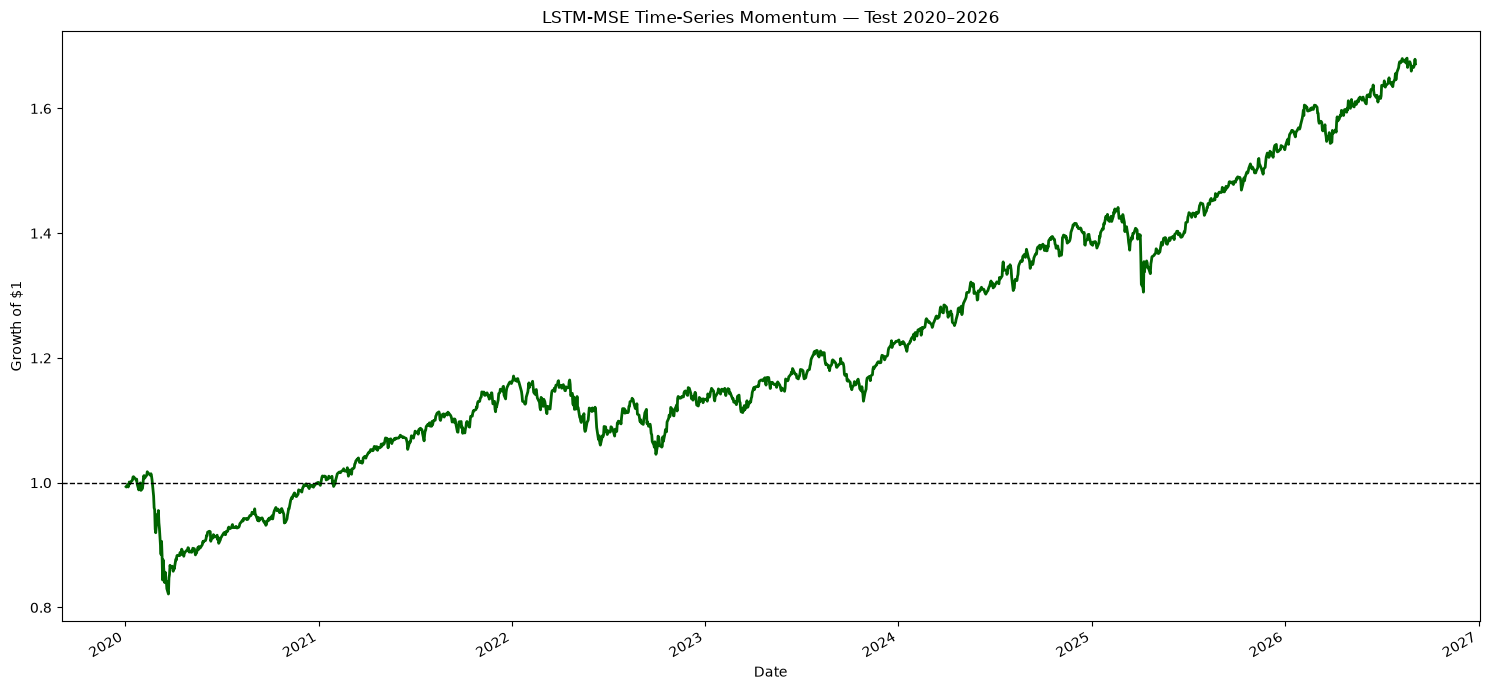

In [40]:
ax = lstm_portfolio_returns[
    "wealth_index"
].plot(
    figsize=(15, 7),
    linewidth=2,
    color="darkgreen",
)

ax.axhline(
    1,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "LSTM-MSE Time-Series Momentum — Test 2020–2026"
)

ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")

plt.tight_layout()
plt.show()

In [41]:
final_wealth = lstm_portfolio_returns[
    "wealth_index"
].iloc[-1]

cumulative_return = final_wealth - 1

print(f"Final wealth      : {final_wealth:.4f}")
print(f"Cumulative return : {cumulative_return:.2%}")

Final wealth      : 1.6716
Cumulative return : 67.16%
